# TBATS Benchmark on M4 Hourly — smooth 1.2.0 (2026-10-06)

The 414 hourly series of the M4 competition, forecast 48 hours ahead with the daily
(24) and weekly (168) periods, and evaluated on the M4 test set by four
implementations of TBATS:

| Method | Call |
|---|---|
| smooth TBATS (Python) | `TBATS(lags=[1, 24, 168]).fit(y)` |
| smooth tbats() (R) | `tbats(ts(y, frequency=24), lags=c(1, 24, 168))` |
| statsforecast AutoTBATS | `AutoTBATS(season_length=[24, 168]).fit(y)` |
| forecast::tbats() | `tbats(msts(y, seasonal.periods=c(24, 168)), use.parallel=FALSE)` |

All with their defaults. Each gives the point forecast and the 99 quantiles at the
levels 0.01, ..., 0.99, from its two-sided prediction intervals at 2%, ..., 98% (the
point forecast is the quantile 0.5; it is the median for all four).

**Metrics**, all scaled by the in-sample one-step differences of the series, `x`:

* RMSSE = sqrt(mean((y - f)²) / mean(diff(x)²)), the root mean squared scaled error;
* SAME = |mean(y - f)| / mean|diff(x)|, the scaled absolute mean error (the bias);
* pinball: the pinball loss at each of the 99 levels, averaged over the horizon and
  divided by mean|diff(x)|, then averaged over the levels;
* calibration: the coverage of each quantile, mean(y ≤ q_τ) over the horizon,
  averaged over the series; MCE is the mean absolute difference between the coverage
  and τ over the 99 levels;
* time: the wall-clock seconds of the fit and the forecast of each series.

**Reproducing.** The notebook loads `2026-10-06-benchmark-tbats-m4-hourly.csv`, one
row per method and series with the metrics, the per-level pinball and coverage, the
time, the selected model and the versions. `BENCH_RERUN=1` (or a missing file)
reruns the whole benchmark through `run_tbats_benchmark.run_all()`: the M4 files are
downloaded and checked against their sha256, smooth's R package is installed from
this working tree, the forecasts of each series are cached in
`~/.cache/smooth-benchmarks/tbats-m4-hourly/` (an interrupted run resumes; delete the
folder to start afresh), and the R methods run from `run_tbats_benchmark.R`.
`BENCH_WORKERS` sets the number of parallel workers (4 here).

**Timing.** The methods run one after another, each on 4 single-threaded workers
(BLAS, OpenMP and numba limited to one thread), after a warm-up fit in each worker,
so the compilation of numba and the loading of the packages are not timed.

In [1]:
import os
import subprocess
import sys
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import run_tbats_benchmark as bench

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

DATE = "2026-10-06"
RESULTS = os.environ.get("BENCH_RESULTS", f"{DATE}-benchmark-tbats-m4-hourly.csv")
METHODS = {"smooth": "smooth TBATS (Python)", "smooth-R": "smooth tbats() (R)",
           "statsforecast": "statsforecast AutoTBATS", "forecast": "forecast::tbats()"}
COLORS = {"smooth": "#1f77b4", "smooth-R": "#17becf", "statsforecast": "#d62728",
          "forecast": "#ff7f0e"}
LEVELS = bench.LEVELS
QS = [f"{int(round(100 * t)):02d}" for t in LEVELS]

## Versions

In [2]:
print(f"python {sys.version.split()[0]}   cores {os.cpu_count()}")
for package in ("smooth", "statsforecast", "numpy", "pandas", "matplotlib"):
    print(f"{package:14s} {version(package)}")
print(subprocess.run(["Rscript", "-e", 'cat(R.version.string, "\nforecast", '
                      'as.character(packageVersion("forecast")), "\n")'],
                     capture_output=True, text=True).stdout)
print("git HEAD:", subprocess.run(["git", "log", "-1", "--format=%h %s"],
                                  capture_output=True, text=True).stdout.strip())

python 3.11.15   cores 4
smooth         1.2.0
statsforecast  2.1.1
numpy          2.4.6
pandas         2.3.3
matplotlib     3.11.2


R version 4.3.3 (2024-02-29) 
forecast 8.21.1 

git HEAD: dada35a tbats: eigenvalues of the admissible bounds without LAPACK, shared by R and Python


## Data

In [3]:
series = bench.data()
ids = list(series)
lengths = pd.Series({sid: len(x) for sid, (x, _) in series.items()})
print(f"{len(series)} series, horizon {bench.H}, periods {bench.LAGS[1:]}")
print(lengths.describe()[["min", "25%", "50%", "75%", "max"]].to_frame("in-sample length").T
      .to_string(float_format=lambda v: f"{v:.0f}"))

414 series, horizon 48, periods [24, 168]
                  min  25%  50%  75%  max
in-sample length  700  700  960  960  960


## Run or load

In [4]:
if os.environ.get("BENCH_RERUN", "0") == "1" or not os.path.exists(RESULTS):
    bench.run_all(RESULTS, int(os.environ.get("BENCH_WORKERS", "4")))
results = pd.read_csv(RESULTS)
results["label"] = results.method.map(METHODS)
print(f"{RESULTS}: {len(results)} rows\n")
check = results.groupby("method").agg(version=("version", "first"), series=("series", "size"),
                                      failed=("rmsse", lambda v: int(v.isna().sum())))
print(check.loc[list(METHODS)].to_string())
assert all(check.series == len(series)), "a method is missing series: rerun to resume"

2026-10-06-benchmark-tbats-m4-hourly.csv: 1656 rows

                                                  version  series  failed
method                                                                   
smooth         smooth 1.2.0 (git dada35a), Python 3.11.15     414       0
smooth-R        smooth 4.6.0.41001 (git dada35a), R 4.3.3     414       0
statsforecast         statsforecast 2.1.1, Python 3.11.15     414       0
forecast                         forecast 8.21.1, R 4.3.3     414       0


## Point forecasts

In [5]:
def wide(column):
    # The metric of every method (columns) and series (rows).
    return results.pivot(index="series", columns="method", values=column).loc[ids, list(METHODS)]


def metric_table(column, label):
    values = wide(column)
    table = pd.DataFrame({"Min": values.min(), "Q1": values.quantile(0.25),
                          "Med": values.median(), "Q3": values.quantile(0.75),
                          "Max": values.max(), "Mean": values.mean(),
                          "Failed": values.isna().sum()})
    table.index = [METHODS[m] for m in table.index]
    print(f"{label}, {len(ids)} series (lower is better)")
    print(table.to_string(float_format=lambda v: f"{v:.4f}"))
    return table


rmsse_table = metric_table("rmsse", "RMSSE")

RMSSE, 414 series (lower is better)
                           Min     Q1    Med     Q3    Max   Mean  Failed
smooth TBATS (Python)   0.0703 0.2913 0.6240 1.1727 4.5617 0.8462       0
smooth tbats() (R)      0.0703 0.2913 0.6240 1.1727 4.5617 0.8462       0
statsforecast AutoTBATS 0.0808 0.3622 0.6876 1.2179 8.6731 1.0410       0
forecast::tbats()       0.0678 0.3279 0.6980 1.2775 7.0543 0.9094       0


In [6]:
same_table = metric_table("same", "SAME")

SAME, 414 series (lower is better)
                           Min     Q1    Med     Q3    Max   Mean  Failed
smooth TBATS (Python)   0.0004 0.1047 0.2654 0.6596 5.6092 0.5726       0
smooth tbats() (R)      0.0004 0.1047 0.2654 0.6596 5.6092 0.5726       0
statsforecast AutoTBATS 0.0000 0.1717 0.3432 0.8420 8.8340 0.7390       0
forecast::tbats()       0.0027 0.1525 0.3168 0.7971 7.0556 0.6370       0


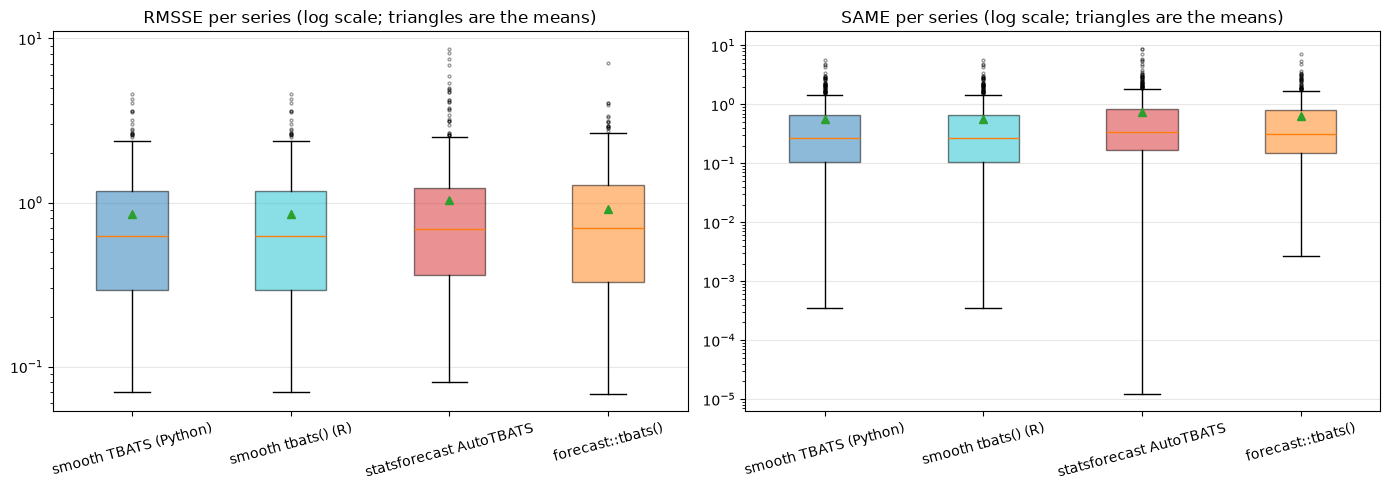

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, column, label in zip(axes, ("rmsse", "same"), ("RMSSE", "SAME")):
    values = wide(column)
    box = ax.boxplot([values[m].dropna() for m in METHODS], showmeans=True, patch_artist=True,
                     flierprops=dict(markersize=2, alpha=0.4))
    for patch, method in zip(box["boxes"], METHODS):
        patch.set(facecolor=COLORS[method], alpha=0.5)
    ax.set_xticks(range(1, len(METHODS) + 1), list(METHODS.values()), rotation=15)
    ax.set_yscale("log")
    ax.set_title(f"{label} per series (log scale; triangles are the means)")
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Series by series

The share of the series where smooth (Python) is more accurate than each of the other
methods, as accurate (to 1e-8), or less accurate.

In [8]:
rows = []
for column, label in (("rmsse", "RMSSE"), ("same", "SAME"), ("pinball", "Pinball")):
    values = wide(column)
    for other in ("statsforecast", "forecast"):
        d = values["smooth"] - values[other]
        rows.append({"Metric": label, "Against": METHODS[other],
                     "smooth better": np.mean(d < -1e-8), "equal": np.mean(np.abs(d) <= 1e-8),
                     "smooth worse": np.mean(d > 1e-8)})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.1%}"))

 Metric                 Against  smooth better  equal  smooth worse
  RMSSE statsforecast AutoTBATS          63.5%   0.0%         36.5%
  RMSSE       forecast::tbats()          58.5%   0.0%         41.5%
   SAME statsforecast AutoTBATS          60.4%   0.0%         39.6%
   SAME       forecast::tbats()          59.2%   0.0%         40.8%
Pinball statsforecast AutoTBATS          66.9%   0.0%         33.1%
Pinball       forecast::tbats()          64.7%   0.0%         35.3%


## Predictive distribution: pinball and calibration

In [9]:
pinball = {m: results.loc[results.method == m, [f"pinball_{q}" for q in QS]].to_numpy(float)
           for m in METHODS}
coverage = {m: results.loc[results.method == m, [f"coverage_{q}" for q in QS]].to_numpy(float)
            for m in METHODS}
rows = []
for m in METHODS:
    curve = np.nanmean(coverage[m], axis=0)
    rows.append({"Method": METHODS[m],
                 "Mean pinball": np.nanmean(pinball[m]),
                 "Median pinball": np.nanmedian(np.nanmean(pinball[m], axis=1)),
                 "MCE": np.nanmean(np.abs(curve - LEVELS)),
                 "Cov@0.1": curve[9], "Cov@0.5": curve[49], "Cov@0.9": curve[89],
                 "80% interval": np.nanmean(coverage[m][:, 89] - coverage[m][:, 9]),
                 "98% interval": np.nanmean(coverage[m][:, 98] - coverage[m][:, 0])})
distribution_table = pd.DataFrame(rows)
print("Scaled pinball and calibration (lower is better for the pinball and MCE; the coverages")
print("should equal their levels, the intervals their nominal coverage)")
print(distribution_table.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Scaled pinball and calibration (lower is better for the pinball and MCE; the coverages
should equal their levels, the intervals their nominal coverage)
                 Method  Mean pinball  Median pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9  80% interval  98% interval
  smooth TBATS (Python)        0.3231          0.2379 0.0517   0.0906   0.4263   0.8475        0.7568        0.9448
     smooth tbats() (R)        0.3231          0.2379 0.0517   0.0906   0.4263   0.8475        0.7568        0.9448
statsforecast AutoTBATS        0.4078          0.2652 0.0669   0.0649   0.4026   0.8530        0.7880        0.9503
      forecast::tbats()        0.3617          0.2771 0.0825   0.0676   0.3771   0.8375        0.7699        0.9466


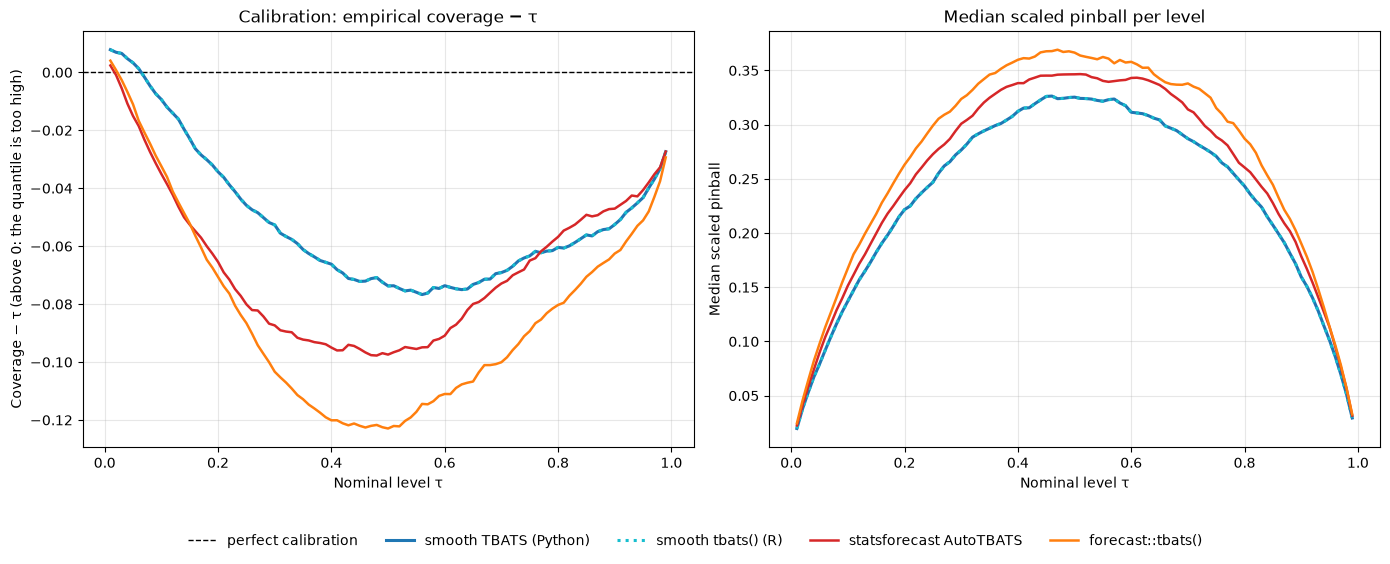

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].axhline(0.0, color="k", ls="--", lw=1, label="perfect calibration")
for m in METHODS:
    style = dict(color=COLORS[m], lw=2.2 if m.startswith("smooth") else 1.8,
                 ls=":" if m == "smooth-R" else "-", label=METHODS[m])
    axes[0].plot(LEVELS, np.nanmean(coverage[m], axis=0) - LEVELS, **style)
    axes[1].plot(LEVELS, np.nanmedian(pinball[m], axis=0), **style)
axes[0].set(title="Calibration: empirical coverage − τ", xlabel="Nominal level τ",
            ylabel="Coverage − τ (above 0: the quantile is too high)")
axes[1].set(title="Median scaled pinball per level", xlabel="Nominal level τ",
            ylabel="Median scaled pinball")
for ax in axes:
    ax.grid(alpha=0.3)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

## Time

In [11]:
times = wide("time")
time_table = pd.DataFrame({"Mean, s": times.mean(), "Median, s": times.median(),
                           "Max, s": times.max(), "Total, h": times.sum() / 3600,
                           "Mean relative to smooth": times.mean() / times["smooth"].mean()})
time_table.index = [METHODS[m] for m in time_table.index]
print("Fit and forecast time per series (4 workers, one thread each)")
print(time_table.to_string(float_format=lambda v: f"{v:.2f}"))

Fit and forecast time per series (4 workers, one thread each)
                         Mean, s  Median, s  Max, s  Total, h  Mean relative to smooth
smooth TBATS (Python)       9.72       8.84   33.81      1.12                     1.00
smooth tbats() (R)         11.38      10.43   42.69      1.31                     1.17
statsforecast AutoTBATS    34.24      30.95  246.59      3.94                     3.52
forecast::tbats()          40.64      38.64   80.50      4.67                     4.18


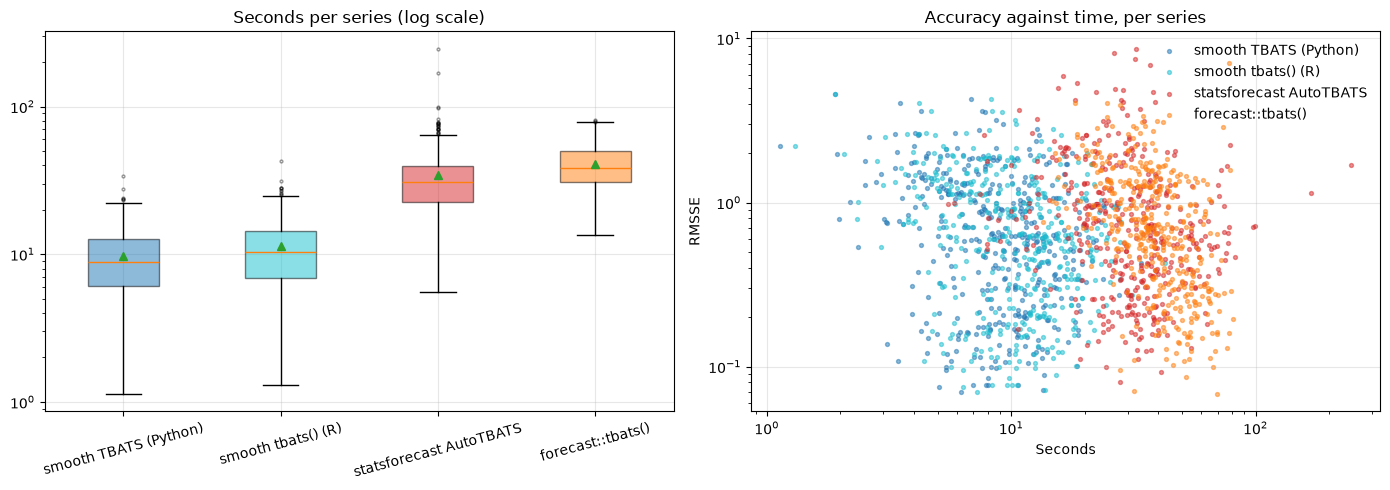

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
box = axes[0].boxplot([times[m] for m in METHODS], showmeans=True, patch_artist=True,
                      flierprops=dict(markersize=2, alpha=0.4))
for patch, method in zip(box["boxes"], METHODS):
    patch.set(facecolor=COLORS[method], alpha=0.5)
axes[0].set_xticks(range(1, len(METHODS) + 1), list(METHODS.values()), rotation=15)
axes[0].set(yscale="log", title="Seconds per series (log scale)")
for m in METHODS:
    axes[1].scatter(times[m], wide("rmsse")[m], s=8, alpha=0.5, color=COLORS[m], label=METHODS[m])
axes[1].set(xscale="log", yscale="log", xlabel="Seconds", ylabel="RMSSE",
            title="Accuracy against time, per series")
axes[1].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Selected models

The structures in the notation of De Livera et al. (2011), TBATS(λ, {p,q}, φ,
<m₁,k₁>, ...), parsed from the model of each series: the share of series with a
Box-Cox transform (λ other than 1), with ARMA errors, with a damped trend, and the
mean number of harmonics of each period (0 when the period is dropped).

In [13]:
import re


def structure(model):
    inner = model[model.index("(") + 1:model.rindex(")")]
    tokens = [t.strip() for t in re.split(r",\s*(?![^{<]*[}>])", inner)]
    p, q = map(int, re.findall(r"\{(\d+),(\d+)\}", inner)[0])
    k = {int(m): int(n) for m, n in re.findall(r"<(\d+),(\d+)>", inner)}
    return {"Box-Cox": tokens[0] not in ("1", "-"), "ARMA": p + q > 0,
            "Damped": tokens[2] not in ("-", "trend"),
            "k(24)": k.get(24, 0), "k(168)": k.get(168, 0)}


ok = results[results.rmsse.notna()]
parsed = pd.DataFrame([structure(m) for m in ok.model], index=ok.index).assign(method=ok.method)
models_table = parsed.groupby("method").mean().loc[list(METHODS)]
models_table.index = [METHODS[m] for m in models_table.index]
print(models_table.to_string(float_format=lambda v: f"{v:.2f}"))

                         Box-Cox  ARMA  Damped  k(24)  k(168)
smooth TBATS (Python)       0.76  0.67    0.80   5.58    5.73
smooth tbats() (R)          0.76  0.67    0.80   5.58    5.73
statsforecast AutoTBATS     0.59  0.69    0.26   5.35    5.62
forecast::tbats()           0.60  0.83    0.36   8.54    4.08


## smooth in R and in Python

The two share the C++ core and fit the same model to every series, with the same
forecasts, so their metrics coincide and only their times differ. This holds since the
eigenvalues of the admissible bounds come from a routine shared by both languages
(`eigenModuliCore()` in `src/headers/eigenCalc.h`): the optima often lie on the boundary
of the admissible region, where R's and NumPy's LAPACK builds disagreed in the last bit,
and with them the two fitted different models to 14 of these series.

In [14]:
same_model = (wide("model")["smooth"] == wide("model")["smooth-R"]).mean()
print(f"same model on {same_model:.1%} of the series")
for column in ("rmsse", "same", "pinball"):
    gap = np.nanmax(np.abs(wide(column)["smooth"] - wide(column)["smooth-R"]))
    print(f"max |Python - R| of {column:8s} {gap:.2e}")

same model on 100.0% of the series
max |Python - R| of rmsse    0.00e+00
max |Python - R| of same     0.00e+00
max |Python - R| of pinball  0.00e+00


### Timing across container sessions

The container restarted twice while forecast::tbats() ran, so its series were fitted
in three sessions (H1–H190, H191–H204, H205–H414) on the same 4-core machine type. Its
time relative to smooth on the same series stays at 4.2–4.4 in each group: the later
series take longer for every method, not because of the sessions. The smooth rows were
refitted in a later session, after the fix of the eigenvalues described below.

In [15]:
k = times.index.str[1:].astype(int)
group = np.where(k <= 190, "H1-H190", np.where(k <= 204, "H191-H204", "H205-H414"))
print(times.assign(group=group, ratio=times["forecast"] / times["smooth"]).groupby("group")
      .agg(series=("ratio", "size"), forecast=("forecast", "median"), smooth=("smooth", "median"),
           ratio=("ratio", "median")).to_string(float_format=lambda v: f"{v:.2f}"))

           series  forecast  smooth  ratio
group                                     
H1-H190       190     33.32    7.79   4.41
H191-H204      14     50.87   11.06   4.23
H205-H414     210     45.75   10.99   4.32


## Findings

* **Accuracy.** smooth is the most accurate of the three implementations on every
  metric: mean RMSSE 0.846 against 0.909 for forecast::tbats() and 1.041 for
  statsforecast (medians 0.624, 0.698, 0.688), mean SAME 0.573 against 0.637 and 0.739.
  It is more accurate than statsforecast on 64% of the series and than forecast on 59%
  by RMSSE. The margin is smaller than on Taylor's series, where forecast::tbats() was
  worse than the seasonal naive.
* **Predictive distribution.** smooth has the lowest pinball (mean 0.323 against 0.362
  and 0.408, median 0.238 against 0.265 and 0.277) and the best calibration (MCE 0.052
  against 0.067 and 0.083). All three put too little mass above their quantiles: the
  coverage is below the level across the range, most around the median (0.43, 0.40
  and 0.38 at τ=0.5), so the forecasts are low on these series. The central intervals
  of smooth cover the least: the 80% interval covers 75.7% (statsforecast 78.8%,
  forecast 77.0%), the 98% one 94.5% (95.0%, 94.7%).
* **Time.** smooth takes 9.7 s per series in Python and 11.4 s in R, statsforecast 34 s
  (3.5 times smooth) and forecast::tbats() 41 s (4.2 times), on one thread each.
* **Models.** smooth uses the Box-Cox transform on 76% of the series, a damped trend
  on 80% and ARMA errors on 67%; forecast takes more daily harmonics (8.5 against 5.6)
  and fewer weekly ones (4.1 against 5.7).
* **R and Python.** smooth fits the same model with the same forecasts in both
  languages on all 414 series.